# Day 2: Tokenization and Vocabulary

This notebook covers how models convert text into numbers using tokenization algorithms like Byte Pair Encoding (BPE), and analyzes token costs across different languages using OpenAI's tiktoken library.

## 1. Setup and Imports

In [16]:
# Install tiktoken if not already installed
# !pip install tiktoken

import re
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import tiktoken

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 2. Why Tokenization Matters

Models don't read words like humans do. They split text into sub-word units called **tokens**.
A token can be a word, part of a word, punctuation, or even a single character.

In [6]:
import tiktoken

enc = tiktoken.get_encoding("cl100k_base")

In [8]:
tokens = enc.encode("Hello, world!")   # → list of token IDs
tokens

[9906, 11, 1917, 0]

In [9]:
text = enc.decode([9906, 11, 1917, 0]) # → "Hello, world!"
text

'Hello, world!'

In [4]:
# Quick intuition: what is a token?
enc = tiktoken.get_encoding('cl100k_base')  # GPT-4 encoding

examples = [
    'Hello, world!',
    'tokenization',
    'unbelievable',
    'ChatGPT',
    '2024'
]

print(f"{'Text':<20} {'Tokens':<10} {'Token IDs'}")
print('='*60)
for text in examples:
    token_ids = enc.encode(text)
    tokens = [enc.decode([t]) for t in token_ids]
    print(f'{text:<20} {len(token_ids):<10} {tokens}')

Text                 Tokens     Token IDs
Hello, world!        4          ['Hello', ',', ' world', '!']
tokenization         2          ['token', 'ization']
unbelievable         3          ['un', 'belie', 'vable']
ChatGPT              3          ['Chat', 'G', 'PT']
2024                 2          ['202', '4']


## 3. Byte Pair Encoding (BPE) — From Scratch

In [5]:
# BPE Algorithm Implementation
def get_vocab(corpus):
    """Convert corpus to character-level vocabulary with end-of-word marker."""
    vocab = Counter()
    for word in corpus.lower().split():
        vocab[' '.join(list(word)) + ' </w>'] += 1
    return vocab

def get_pairs(vocab):
    """Count all adjacent symbol pairs in vocabulary."""
    pairs = Counter()
    for word, freq in vocab.items():
        symbols = word.split()
        for i in range(len(symbols) - 1):
            pairs[(symbols[i], symbols[i+1])] += freq
    return pairs

def merge_vocab(pair, vocab):
    """Merge the most frequent pair in vocabulary."""
    new_vocab = {}
    bigram = ' '.join(pair)
    replacement = ''.join(pair)
    for word in vocab:
        new_word = word.replace(bigram, replacement)
        new_vocab[new_word] = vocab[word]
    return new_vocab

# Run BPE on a small corpus
corpus = 'low lower lowest new newer newest'
vocab = get_vocab(corpus)

print('Initial vocabulary (character-level):')
for word, freq in vocab.items():
    print(f'  {word!r}: {freq}')

print('\nRunning 10 BPE merge operations...')
for i in range(10):
    pairs = get_pairs(vocab)
    if not pairs:
        break
    best = pairs.most_common(1)[0][0]
    vocab = merge_vocab(best, vocab)
    print(f'  Merge {i+1}: {best[0]!r} + {best[1]!r} → {"".join(best)!r}')

print('\nFinal vocabulary:')
for word, freq in vocab.items():
    print(f'  {word!r}: {freq}')

Initial vocabulary (character-level):
  'l o w </w>': 1
  'l o w e r </w>': 1
  'l o w e s t </w>': 1
  'n e w </w>': 1
  'n e w e r </w>': 1
  'n e w e s t </w>': 1

Running 10 BPE merge operations...
  Merge 1: 'w' + 'e' → 'we'
  Merge 2: 'l' + 'o' → 'lo'
  Merge 3: 'n' + 'e' → 'ne'
  Merge 4: 'w' + '</w>' → 'w</w>'
  Merge 5: 'lo' + 'we' → 'lowe'
  Merge 6: 'r' + '</w>' → 'r</w>'
  Merge 7: 's' + 't' → 'st'
  Merge 8: 'st' + '</w>' → 'st</w>'
  Merge 9: 'ne' + 'we' → 'newe'
  Merge 10: 'lo' + 'w</w>' → 'low</w>'

Final vocabulary:
  'low</w>': 1
  'lowe r</w>': 1
  'lowe st</w>': 1
  'ne w</w>': 1
  'newe r</w>': 1
  'newe st</w>': 1


## 4. tiktoken — OpenAI's Tokenizer

In [10]:
# Compare different encodings used by OpenAI models
encodings = {
    'gpt2': tiktoken.get_encoding('gpt2'),
    'cl100k_base': tiktoken.get_encoding('cl100k_base'),   # GPT-3.5, GPT-4
    'o200k_base': tiktoken.get_encoding('o200k_base'),     # GPT-4o
}

test_text = 'Tokenization is the foundation of all language models.'

print(f'Text: "{test_text}"\n')
print(f"{'Encoding':<20} {'Token Count':<15} {'Tokens'}")
print('='*70)
for name, enc in encodings.items():
    ids = enc.encode(test_text)
    tokens = [enc.decode([t]) for t in ids]
    print(f'{name:<20} {len(ids):<15} {tokens}')

Text: "Tokenization is the foundation of all language models."

Encoding             Token Count     Tokens
gpt2                 10              ['Token', 'ization', ' is', ' the', ' foundation', ' of', ' all', ' language', ' models', '.']
cl100k_base          10              ['Token', 'ization', ' is', ' the', ' foundation', ' of', ' all', ' language', ' models', '.']
o200k_base           10              ['Token', 'ization', ' is', ' the', ' foundation', ' of', ' all', ' language', ' models', '.']


In [12]:
# Compare different encodings used by OpenAI models
encodings = {
    'gpt2': tiktoken.get_encoding('gpt2'),
    'cl100k_base': tiktoken.get_encoding('cl100k_base'),   # GPT-3.5, GPT-4
    'o200k_base': tiktoken.get_encoding('o200k_base'),     # GPT-4o
}

test_text = 'Bugün ekmek almaya markete gittim ve yeni gelen sebzeleri gördüm'

print(f'Text: "{test_text}"\n')
print(f"{'Encoding':<20} {'Token Count':<15} {'Tokens'}")
print('='*70)
for name, enc in encodings.items():
    ids = enc.encode(test_text)
    tokens = [enc.decode([t]) for t in ids]
    print(f'{name:<20} {len(ids):<15} {tokens}')

Text: "Bugün ekmek almaya markete gittim ve yeni gelen sebzeleri gördüm"

Encoding             Token Count     Tokens
gpt2                 28              ['Bug', 'ü', 'n', ' e', 'km', 'ek', ' al', 'may', 'a', ' market', 'e', ' g', 'itt', 'im', ' ve', ' yen', 'i', ' gel', 'en', ' se', 'b', 'zel', 'eri', ' g', 'ö', 'rd', 'ü', 'm']
cl100k_base          23              ['Bug', 'ün', ' e', 'km', 'ek', ' alm', 'aya', ' market', 'e', ' g', 'itt', 'im', ' ve', ' yeni', ' g', 'elen', ' se', 'bz', 'eler', 'i', ' gö', 'rd', 'üm']
o200k_base           18              ['Bug', 'ün', ' ek', 'mek', ' alm', 'aya', ' market', 'e', ' gitt', 'im', ' ve', ' yeni', ' gelen', ' seb', 'z', 'eleri', ' görd', 'üm']


## 5. Token Cost Analysis Across Languages

In [11]:
# Same sentence translated into multiple languages
# 'Artificial intelligence is transforming the world.'
multilingual_texts = {
    'English':    'Artificial intelligence is transforming the world.',
    'Turkish':    'Yapay zeka dünyayı dönüştürüyor.',
    'Spanish':    'La inteligencia artificial está transformando el mundo.',
    'French':     'L\'intelligence artificielle transforme le monde.',
    'German':     'Künstliche Intelligenz verändert die Welt.',
    'Chinese':    '人工智能正在改变世界。',
    'Japanese':   '人工知能は世界を変えています。',
    'Arabic':     'الذكاء الاصطناعي يغير العالم.',
    'Russian':    'Искусственный интеллект меняет мир.',
    'Korean':     '인공지능이 세상을 변화시키고 있습니다.',
}

enc = tiktoken.get_encoding('cl100k_base')

results = []
for lang, text in multilingual_texts.items():
    token_ids = enc.encode(text)
    char_count = len(text)
    token_count = len(token_ids)
    results.append({
        'Language': lang,
        'Characters': char_count,
        'Tokens': token_count,
        'Chars/Token': round(char_count / token_count, 2)
    })

df = pd.DataFrame(results).sort_values('Tokens', ascending=False)
print('Token cost comparison (cl100k_base / GPT-4):')
print(df.to_string(index=False))

Token cost comparison (cl100k_base / GPT-4):
Language  Characters  Tokens  Chars/Token
  Arabic          29      20         1.45
 Russian          35      18         1.94
  Korean          21      18         1.17
 Turkish          32      17         1.88
Japanese          15      15         1.00
  German          42      13         3.23
  French          48      12         4.00
 Chinese          11      12         0.92
 Spanish          55      10         5.50
 English          50       8         6.25


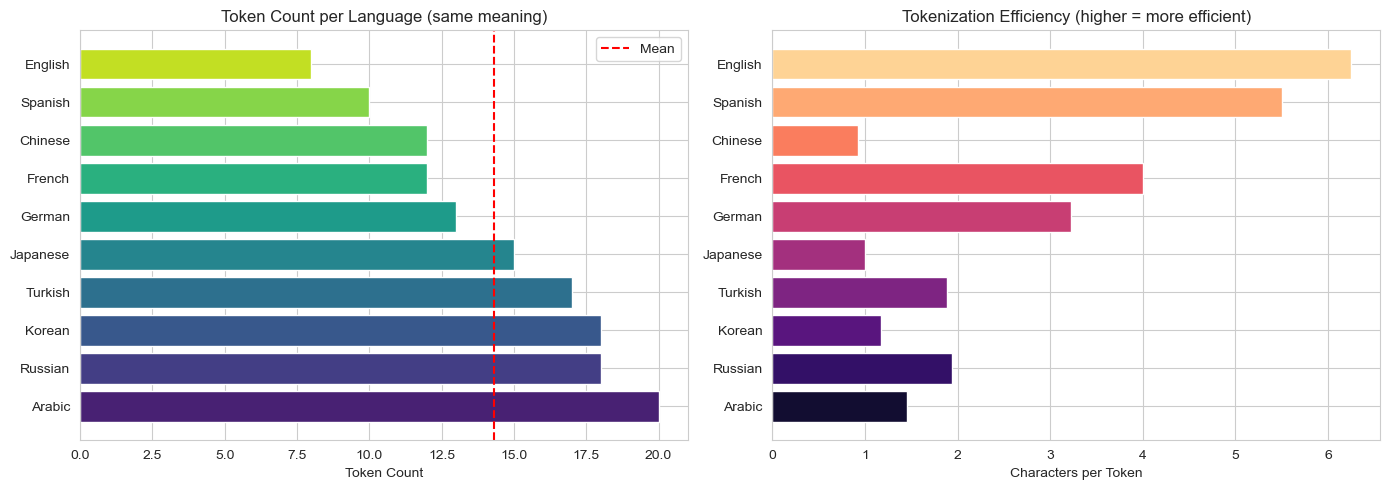


Most efficient: English (6.25 chars/token)
Least efficient: Arabic (1.45 chars/token)


In [13]:
# Visualize token counts by language
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: token counts
axes[0].barh(df['Language'], df['Tokens'], color=sns.color_palette('viridis', len(df)))
axes[0].set_xlabel('Token Count')
axes[0].set_title('Token Count per Language (same meaning)')
axes[0].axvline(df['Tokens'].mean(), color='red', linestyle='--', label='Mean')
axes[0].legend()

# Bar chart: chars per token (efficiency)
axes[1].barh(df['Language'], df['Chars/Token'], color=sns.color_palette('magma', len(df)))
axes[1].set_xlabel('Characters per Token')
axes[1].set_title('Tokenization Efficiency (higher = more efficient)')

plt.tight_layout()
plt.show()

print(f'\nMost efficient: {df.iloc[-1]["Language"]} ({df.iloc[-1]["Chars/Token"]} chars/token)')
print(f'Least efficient: {df.iloc[0]["Language"]} ({df.iloc[0]["Chars/Token"]} chars/token)')

## 6. Special Tokens and Chat Templates

In [14]:
# Special tokens used in chat models
enc = tiktoken.get_encoding('cl100k_base')

special_tokens = ['<|endoftext|>', '<|fim_prefix|>', '<|fim_middle|>', '<|fim_suffix|>']
print('Special tokens in cl100k_base:')
for token in special_tokens:
    try:
        token_id = enc.encode(token, allowed_special={token})
        print(f'  {token!r} → ID: {token_id}')
    except Exception as e:
        print(f'  {token!r} → {e}')

# Simulate a chat message token count
print('\n--- Chat Message Token Counting ---')
messages = [
    {'role': 'system', 'content': 'You are a helpful assistant.'},
    {'role': 'user', 'content': 'What is tokenization?'},
    {'role': 'assistant', 'content': 'Tokenization is the process of splitting text into tokens.'}
]

total_tokens = 0
for msg in messages:
    content_tokens = len(enc.encode(msg['content']))
    role_tokens = len(enc.encode(msg['role']))
    msg_tokens = content_tokens + role_tokens + 4  # overhead per message
    total_tokens += msg_tokens
    print(f'  [{msg["role"]}] {content_tokens} content tokens + {role_tokens} role tokens = {msg_tokens}')

total_tokens += 2  # conversation overhead
print(f'\nEstimated total tokens for this conversation: {total_tokens}')

Special tokens in cl100k_base:
  '<|endoftext|>' → ID: [100257]
  '<|fim_prefix|>' → ID: [100258]
  '<|fim_middle|>' → ID: [100259]
  '<|fim_suffix|>' → ID: [100260]

--- Chat Message Token Counting ---
  [system] 6 content tokens + 1 role tokens = 11
  [user] 5 content tokens + 1 role tokens = 10
  [assistant] 11 content tokens + 1 role tokens = 16

Estimated total tokens for this conversation: 39


## 7. Tokenization Edge Cases

In [17]:
enc = tiktoken.get_encoding('cl100k_base')

def show_tokens(text, label=''):
    ids = enc.encode(text)
    tokens = [enc.decode([t]) for t in ids]
    print(f'{label or text!r}')
    print(f'  Tokens ({len(ids)}): {tokens}')
    print()

print('=== EDGE CASE 1: Numbers ===')
show_tokens('1234567890', 'Large number')
show_tokens('3.14159265', 'Pi')

print('=== EDGE CASE 2: Whitespace ===')
show_tokens('hello world', 'Single space')
show_tokens('hello  world', 'Double space')
show_tokens('hello\nworld', 'Newline')

print('=== EDGE CASE 3: Code ===')
show_tokens('def hello_world():', 'Python function')
show_tokens('console.log("hello")', 'JavaScript')

print('=== EDGE CASE 4: Capitalization ===')
show_tokens('hello', 'lowercase')
show_tokens('Hello', 'Capitalized')
show_tokens('HELLO', 'UPPERCASE')

=== EDGE CASE 1: Numbers ===
'Large number'
  Tokens (4): ['123', '456', '789', '0']

'Pi'
  Tokens (5): ['3', '.', '141', '592', '65']

=== EDGE CASE 2: Whitespace ===
'Single space'
  Tokens (2): ['hello', ' world']

'Double space'
  Tokens (3): ['hello', ' ', ' world']

'Newline'
  Tokens (3): ['hello', '\n', 'world']

=== EDGE CASE 3: Code ===
'Python function'
  Tokens (4): ['def', ' hello', '_world', '():']

'JavaScript'
  Tokens (5): ['console', '.log', '("', 'hello', '")']

=== EDGE CASE 4: Capitalization ===
'lowercase'
  Tokens (1): ['hello']

'Capitalized'
  Tokens (1): ['Hello']

'UPPERCASE'
  Tokens (2): ['HEL', 'LO']



## 8. Vocabulary Size Comparison

Vocabulary sizes:
  GPT-2 (gpt2): 50,257 tokens
  GPT-3.5/4 (cl100k_base): 100,277 tokens
  GPT-4o (o200k_base): 200,019 tokens


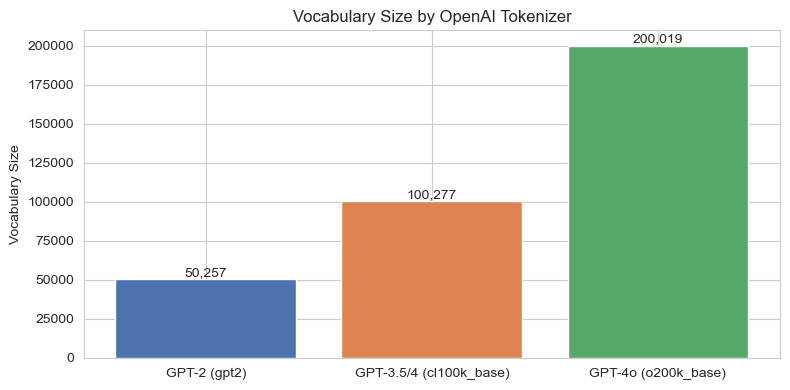

In [18]:
# Vocabulary sizes of different tokenizers
vocab_sizes = {
    'GPT-2 (gpt2)': tiktoken.get_encoding('gpt2').n_vocab,
    'GPT-3.5/4 (cl100k_base)': tiktoken.get_encoding('cl100k_base').n_vocab,
    'GPT-4o (o200k_base)': tiktoken.get_encoding('o200k_base').n_vocab,
}

print('Vocabulary sizes:')
for model, size in vocab_sizes.items():
    print(f'  {model}: {size:,} tokens')

# Visualize
plt.figure(figsize=(8, 4))
bars = plt.bar(vocab_sizes.keys(), vocab_sizes.values(),
               color=['#4C72B0', '#DD8452', '#55A868'])
plt.ylabel('Vocabulary Size')
plt.title('Vocabulary Size by OpenAI Tokenizer')
for bar, val in zip(bars, vocab_sizes.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
             f'{val:,}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 9. Practical: Estimating API Costs

In [19]:
enc = tiktoken.get_encoding('cl100k_base')

# GPT-4o pricing (as of 2024, per 1M tokens)
PRICING = {
    'gpt-4o': {'input': 5.00, 'output': 15.00},
    'gpt-4o-mini': {'input': 0.15, 'output': 0.60},
    'gpt-3.5-turbo': {'input': 0.50, 'output': 1.50},
}

def estimate_cost(prompt, expected_output_tokens, model='gpt-4o'):
    input_tokens = len(enc.encode(prompt))
    price = PRICING[model]
    input_cost = (input_tokens / 1_000_000) * price['input']
    output_cost = (expected_output_tokens / 1_000_000) * price['output']
    return input_tokens, input_cost + output_cost

# Example prompts
prompts = [
    ('Short prompt', 'Summarize NLP in one sentence.', 50),
    ('Medium prompt', 'Explain the difference between stemming and lemmatization with examples.', 200),
    ('Long prompt', 'Write a detailed tutorial on Byte Pair Encoding covering history, algorithm steps, advantages, and code examples.' * 3, 500),
]

print(f"{'Prompt':<15} {'Input Tokens':<15} {'gpt-4o':<12} {'gpt-4o-mini':<15} {'gpt-3.5-turbo'}")
print('='*75)
for label, prompt, out_tokens in prompts:
    costs = {}
    for model in PRICING:
        n_tokens, cost = estimate_cost(prompt, out_tokens, model)
        costs[model] = (n_tokens, cost)
    n_tok = costs['gpt-4o'][0]
    print(f'{label:<15} {n_tok:<15} ${costs["gpt-4o"][1]:.5f}     ${costs["gpt-4o-mini"][1]:.5f}       ${costs["gpt-3.5-turbo"][1]:.5f}')

Prompt          Input Tokens    gpt-4o       gpt-4o-mini     gpt-3.5-turbo
Short prompt    9               $0.00080     $0.00003       $0.00008
Medium prompt   14              $0.00307     $0.00012       $0.00031
Long prompt     58              $0.00779     $0.00031       $0.00078


## 10. Limitations of Current Tokenization

In [20]:
enc = tiktoken.get_encoding('cl100k_base')

print('=== LIMITATION 1: Arithmetic is hard ===')
# Numbers split into multiple tokens make arithmetic harder
for num in ['100', '1000', '10000', '99999']:
    ids = enc.encode(num)
    print(f'  {num!r} → {len(ids)} token(s): {[enc.decode([t]) for t in ids]}')

print('\n=== LIMITATION 2: Non-Latin scripts are expensive ===')
pairs = [
    ('Hello', 'Merhaba'),
    ('Good morning', 'おはようございます'),
    ('Thank you', '谢谢你'),
]
for en, other in pairs:
    en_t = len(enc.encode(en))
    other_t = len(enc.encode(other))
    print(f'  {en!r} ({en_t} tokens) vs {other!r} ({other_t} tokens)')

print('\n=== LIMITATION 3: Tokenization affects model behavior ===')
# The famous 'SolidGoldMagikarp' problem — rare tokens can cause unexpected behavior
rare_words = ['Tokenization', 'GPT', 'BERT', 'SolidGoldMagikarp']
for word in rare_words:
    ids = enc.encode(word)
    print(f'  {word!r} → {len(ids)} token(s): {[enc.decode([t]) for t in ids]}')

print('\n=== WHY BETTER TOKENIZATION MATTERS ===')
print('✓ Fewer tokens = lower API cost')
print('✓ Fewer tokens = longer effective context window')
print('✓ Better token boundaries = better model reasoning')
print('✓ Language-fair tokenization = equal performance across languages')

=== LIMITATION 1: Arithmetic is hard ===
  '100' → 1 token(s): ['100']
  '1000' → 2 token(s): ['100', '0']
  '10000' → 2 token(s): ['100', '00']
  '99999' → 2 token(s): ['999', '99']

=== LIMITATION 2: Non-Latin scripts are expensive ===
  'Hello' (1 tokens) vs 'Merhaba' (3 tokens)
  'Good morning' (2 tokens) vs 'おはようございます' (6 tokens)
  'Thank you' (2 tokens) vs '谢谢你' (5 tokens)

=== LIMITATION 3: Tokenization affects model behavior ===
  'Tokenization' → 2 token(s): ['Token', 'ization']
  'GPT' → 2 token(s): ['G', 'PT']
  'BERT' → 1 token(s): ['BERT']
  'SolidGoldMagikarp' → 5 token(s): ['Solid', 'Gold', 'Mag', 'ik', 'arp']

=== WHY BETTER TOKENIZATION MATTERS ===
✓ Fewer tokens = lower API cost
✓ Fewer tokens = longer effective context window
✓ Better token boundaries = better model reasoning
✓ Language-fair tokenization = equal performance across languages


## Summary

Today we covered:
1. **Why tokenization**: Models work with numbers, not text
2. **BPE from scratch**: How sub-word merging builds a vocabulary
3. **tiktoken**: OpenAI's production tokenizer
4. **Multilingual token costs**: Non-Latin scripts use more tokens
5. **Special tokens**: How chat templates are structured
6. **Edge cases**: Numbers, whitespace, capitalization quirks
7. **Vocabulary sizes**: How they grew from GPT-2 to GPT-4o
8. **API cost estimation**: Tokens directly map to cost
9. **Limitations**: Why tokenization still causes model failures

Next up: **Word Embeddings** — how tokens become dense semantic vectors.